In [1]:
import pandas as pd
import os

# 定义基础路径和要处理的文件列表
base_path = '../../../5_Data/bupt_ring_selftest/wsx/报告/0526-1109-0527-1032/'
# base_path = 'wang戒指/'
# 根据截图生成 wang戒指1.csv 到 wang戒指4.csv
file_names = [f'wang戒指{i}.csv' for i in range(1, 5)]

all_parsed_rows = []

# 遍历所有文件
for file_name in file_names:
    file_path = os.path.join(base_path, file_name)
    print(f"正在处理: {file_name} ...")
    
    current_date, current_time, current_offset = "", "", ""
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                
                # 忽略空行和 '}'
                if not line or line == '}':
                    continue
                
                # 提取时间戳逻辑
                if ',' in line:
                    parts = line.split(',', 3)
                    current_date = parts[0].strip()
                    current_time = parts[1].strip()
                    current_offset = parts[2].strip()
                    # 增加健壮性，防止某些行只有逗号没有数据
                    data_part = parts[3].strip() if len(parts) > 3 else "" 
                else:
                    data_part = line
                    
                row_dict = {
                    'File_Source': file_name,  # 添加文件来源标识，方便后续分析
                    'Date': current_date,
                    'Time': current_time,
                    'Duration': current_offset
                }
                
                # 提取各个传感器数据
                if data_part:
                    kv_pairs = data_part.split(';')
                    for kv in kv_pairs:
                        if ':' in kv:
                            key, value = kv.split(':', 1)
                            row_dict[key.strip()] = value.strip()
                            
                    all_parsed_rows.append(row_dict)
                    
    except FileNotFoundError:
        print(f"⚠️ 警告: 未找到文件 {file_path}，已跳过。")

# 将所有解析出的行转换为一个统一的 DataFrame
df = pd.DataFrame(all_parsed_rows)

print(f"\n✅ 数据拼接完成！合并后的 DataFrame 总行数: {len(df)}")
df.to_csv(os.path.join(base_path, 'wang戒指_merged.csv'), index=False, encoding='utf-8') # 可选：将合并后的数据导出保存

正在处理: wang戒指1.csv ...
正在处理: wang戒指2.csv ...
正在处理: wang戒指3.csv ...
正在处理: wang戒指4.csv ...

✅ 数据拼接完成！合并后的 DataFrame 总行数: 8506695


In [2]:
df.drop("File_Source", inplace=True, axis=1)

In [3]:
df.columns = ['Date', 'Time', 'Duration', 'red', 'ied', 'accX', 'accY', 'accZ']
# 指定需要转换的列名
cols_to_convert = ['red', 'ied', 'accX', 'accY', 'accZ']

# 批量转换
df[cols_to_convert] = df[cols_to_convert].astype(float)

# 检查转换后的类型
print(df.dtypes)

Date            str
Time            str
Duration        str
red         float64
ied         float64
accX        float64
accY        float64
accZ        float64
dtype: object


In [1]:
import pandas as pd

In [11]:
df = pd.read_csv("D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/ring_full.csv")

In [3]:
import numpy as np
import math

In [12]:
def c_style_median_of_3(a, b, c):
    if a > b:
        if b > c:
            return b
        elif a > c:
            return c
        else:
            return a
    else:
        if a > c:
            return a
        elif b > c:
            return c
        else:
            return b

def process_ppg_pipeline_commercial(df, sampling_rate_hz=100):
    MAX_SLEW_RATE = 50000.0
    DC_ALPHA = 0.95
    time_per_point_ms = 1000.0 / sampling_rate_hz 
    
    prev_clean_y = None
    ring_buf = [0.0, 0.0, 0.0]
    buf_idx = 0
    buf_filled = False
    prev_raw_dc = None
    prev_ac_y = 0.0
    
    PHASE_WAITING_FOR_PEAK = 1
    PHASE_WAITING_FOR_VALLEY = 0
    current_phase = PHASE_WAITING_FOR_VALLEY
    
    # [放宽 1] 允许更微弱的脉冲信号通过
    upper_th = 5000.0; lower_th = -5000.0; MIN_AC_AMP = 500.0
    
    local_max = float('-inf'); local_max_x = 0
    local_min = float('inf'); local_min_x = 0
    v1_x = 0; v1_y = 0.0
    
    # [新增] 用于记录精确（带有小数）的上一个谷底位置
    precise_v1_x = 0.0 
    
    run_sum = 0.0; run_enmo = 0.0; run_pts = 0
    snap_area = 0.0; snap_enmo = 0.0; snap_pts = 0
    area_up_saved = 0.0
    
    baseline_rri = 0.0       
    display_hr_state = 0.0   
    baseline_1g = 0.0
    
    extracted_features = []
    
    # [新增] 初始化一个数组，用于记录所有的 ac_y 值，以便进行插值回溯
    ac_y_history = np.zeros(len(df))

    for i, row in enumerate(df.itertuples()):
        # 【修正硬件极性反转】
        raw_y = float(row.green2) * -1.0
        
        # acc_x, acc_y, acc_z = float(row.accX), float(row.accY), float(row.accZ)
        # if math.isnan(acc_x) or math.isnan(acc_y) or math.isnan(acc_z):
        #     acc_norm = baseline_1g if baseline_1g != 0.0 else 2000.0 
        # else:
        #     acc_norm = math.sqrt(acc_x**2 + acc_y**2 + acc_z**2)
        
        # if baseline_1g == 0.0:
        #     baseline_1g = acc_norm
            
        # enmo = abs(acc_norm - baseline_1g)
        # if enmo < 300.0:
        #     baseline_1g = baseline_1g * 0.99 + acc_norm * 0.01
        
        if prev_clean_y is None: clamped_y = raw_y
        else:
            diff = raw_y - prev_clean_y
            if diff > MAX_SLEW_RATE: clamped_y = prev_clean_y + MAX_SLEW_RATE
            elif diff < -MAX_SLEW_RATE: clamped_y = prev_clean_y - MAX_SLEW_RATE
            else: clamped_y = raw_y
        prev_clean_y = clamped_y
        
        ring_buf[buf_idx] = clamped_y
        buf_idx = (buf_idx + 1) % 3
        buf_filled = buf_filled or (buf_idx == 0)
        final_raw_y = c_style_median_of_3(ring_buf[0], ring_buf[1], ring_buf[2]) if buf_filled else clamped_y
            
        if prev_raw_dc is None: 
            prev_raw_dc = final_raw_y
            ac_y = 0.0
        else: 
            ac_y = final_raw_y - prev_raw_dc + DC_ALPHA * prev_ac_y
        prev_raw_dc = final_raw_y
        prev_ac_y = ac_y
        
        # [新增] 记录当前的交流信号，供后续寻峰回溯
        ac_y_history[i] = ac_y

        upper_th -= (upper_th / 256.0)
        lower_th -= (lower_th / 256.0)
        if upper_th < MIN_AC_AMP: upper_th = MIN_AC_AMP
        if lower_th > -MIN_AC_AMP: lower_th = -MIN_AC_AMP
        if ac_y > upper_th: upper_th = ac_y
        if ac_y < lower_th: lower_th = ac_y

        if current_phase == PHASE_WAITING_FOR_VALLEY:
            run_sum += ac_y
            run_enmo += enmo
            run_pts += 1
            
            if ac_y < local_min:
                local_min = ac_y
                local_min_x = i
                snap_area = run_sum
                snap_enmo = run_enmo
                snap_pts = run_pts
            
            if ac_y > upper_th * 0.15:
                v2_x = local_min_x
                v2_y = local_min
                
                # ---------- [新增] 核心改进 1：抛物线插值，计算亚采样点精确位置 ----------
                if 0 < v2_x < len(df) - 1:
                    y_m1 = ac_y_history[v2_x - 1]
                    y_0  = ac_y_history[v2_x]
                    y_p1 = ac_y_history[v2_x + 1]
                    
                    denom = y_m1 - 2 * y_0 + y_p1
                    if denom != 0:
                        delta_x = 0.5 * (y_m1 - y_p1) / denom
                        # 限制偏移量在合理范围内 [-1.0, 1.0]，防止波形畸变导致飞逸
                        delta_x = max(-1.0, min(1.0, delta_x))
                    else:
                        delta_x = 0.0
                else:
                    delta_x = 0.0
                
                # 得到带有小数的高精度谷底坐标
                precise_v2_x = float(v2_x) + delta_x
                # ----------------------------------------------------------------------
                
                # [修改] 使用精确的坐标来计算 RR 间期
                if precise_v1_x > 0.0:
                    rri_ms = (precise_v2_x - precise_v1_x) * time_per_point_ms
                    area_down = snap_area - (snap_pts * v2_y)
                    total_pts = snap_pts + run_pts
                    
                    if 300 <= rri_ms <= 2500 and area_down > 0:
                        if baseline_rri == 0.0:
                            baseline_rri = rri_ms
                            display_hr_state = 60000.0 / rri_ms
                            
                        # [放宽 2] 允许更剧烈的心率突变和极低心率
                        is_valid_beat = True
                        if rri_ms > baseline_rri * 1.8: is_valid_beat = False      
                        elif rri_ms < baseline_rri * 0.45: is_valid_beat = False   
                        elif rri_ms > 2000.0: is_valid_beat = False                
                            
                        if is_valid_beat:
                            raw_hr = 60000.0 / rri_ms
                            baseline_rri = baseline_rri * 0.75 + rri_ms * 0.25
                            display_hr_state = display_hr_state * 0.85 + raw_hr * 0.15
                            motion_mean = (snap_enmo + run_enmo) / (total_pts if total_pts > 0 else 1)

                            amp_up = local_max - v1_y
                            amp_down = local_max - v2_y
                            
                            MIN_VALID_AMP = 15.0  
                            
                            # =========================================================
                            # 【核心修改区：直接保留原始积分数值，不做任何时间/振幅上的缩放】
                            # =========================================================
                            if amp_up > MIN_VALID_AMP:
                                raw_area_up = area_up_saved
                            else:
                                raw_area_up = 0.0
                                
                            if amp_down > MIN_VALID_AMP:
                                raw_area_down = area_down
                            else:
                                raw_area_down = 0.0
                            # =========================================================

                            record_datetime = f"{getattr(row, 'Date', '')} {getattr(row, 'Time', '')}".strip()
                            
                            extracted_features.append({
                                'datetime': record_datetime if record_datetime else f"Point_{i}",
                                'rri_raw': round(rri_ms, 2),                 
                                'hr_raw': round(raw_hr, 1),             
                                'hr_display': int(display_hr_state),    
                                # [修改] 键名对齐为 area_up 和 area_down，强转为 int 以匹配另一款设备
                                'area_up': int(raw_area_up),     
                                'area_down': int(raw_area_down), 
                                'motion': int(motion_mean) if not math.isnan(motion_mean) else 0,

                                # ==================================
                                # 【新增】存下波峰和波谷的绝对索引
                                # ==================================
                                'peak_idx': int(local_max_x), # 当前周期的波峰索引
                                'valley_idx': int(v2_x)       # 当前周期的结束波谷索引 (v1_x 则是上一个周期的)
                            })

                v1_x = v2_x
                # [新增] 同步更新高精度坐标锚点
                precise_v1_x = precise_v2_x 
                v1_y = v2_y
                local_max = float('-inf')
                
                over_run_sum = run_sum - snap_area
                over_run_pts = run_pts - snap_pts
                carried_area = over_run_sum - (over_run_pts * v1_y)
                
                run_sum = carried_area if carried_area > 0 else 0.0
                run_enmo = run_enmo - snap_enmo
                run_pts = over_run_pts
                current_phase = PHASE_WAITING_FOR_PEAK

        elif current_phase == PHASE_WAITING_FOR_PEAK:
            current_height = ac_y - v1_y
            if current_height > 0:
                run_sum += current_height
                
            run_enmo += enmo
            run_pts += 1
            
            if ac_y > local_max:
                local_max = ac_y
                local_max_x = i
                snap_area = run_sum
                snap_enmo = run_enmo
                snap_pts = run_pts

            if ac_y < lower_th * 0.15:
                area_up_saved = snap_area
                local_min = float('inf')
                
                over_run_sum = run_sum - snap_area
                over_run_pts = run_pts - snap_pts
                run_sum = over_run_sum + (over_run_pts * v1_y)
                run_enmo = run_enmo - snap_enmo
                run_pts = over_run_pts
                current_phase = PHASE_WAITING_FOR_VALLEY

    return pd.DataFrame(extracted_features)

In [13]:
# ==========================================
# 测试与运行区
# ==========================================
if __name__ == '__main__':
    # ---------------------------------------------------------
    # 选项 1：加载你的真实 CSV 数据
    # 当准备好跑真实数据时，取消下面两行的注释，并注释掉选项 2 即可
    # ---------------------------------------------------------
    # df = pd.read_csv("your_real_data.csv")
    fs = 100
    
    # ---------------------------------------------------------
    # 启动流水线
    # ---------------------------------------------------------
    df = df.ffill().fillna(0)
    print("\n启动 C 风格流式处理管道...")
    result_df = process_ppg_pipeline_commercial(df, sampling_rate_hz=fs)

    if result_df.empty:
        print("未能提取到完整周期，请检查数据或阈值。")
    else:
        print("\n=== 特征提取结果 ===")
        # print(result_df.to_string())
        print(f"\n✅ 成功提取出 {len(result_df)} 个有效心跳周期的特征！")


启动 C 风格流式处理管道...


AttributeError: 'Pandas' object has no attribute 'accX'

In [18]:
result_df.dtypes

datetime          str
rri_raw       float64
hr_raw        float64
hr_display      int64
area_up         int64
area_down       int64
motion          int64
peak_idx        int64
valley_idx      int64
dtype: object

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# 1. 准备原始背景信号
y = -1. * df['green2'].values
ymin, ymax = np.nanmin(y), np.nanmax(y)

# 2. 提前把特征点的索引提取为 NumPy 数组（提升性能）
# 假设流水线跑出来的结果存在 result_df 中
peaks_idx = result_df['peak_idx'].values
valleys_idx = result_df['valley_idx'].values

@interact(
    start=IntSlider(min=0, max=len(y)-200, step=100, value=10000, description='start idx'),
    window=IntSlider(min=200, max=10000, step=200, value=1000, description='window')
)
def plot_zoom(start=0, window=500):
    end = min(start + window, len(y))
    t = np.arange(start, end) / 100.0
    
    plt.rcParams['font.size'] = 14
    fig, ax = plt.subplots(figsize=(18, 7))
    
    # 【画底层背景波形】
    ax.plot(t, y[start:end], '-', color='#1f77b4', linewidth=1.5, alpha=0.8, label='Raw PPG (IED inverted)')
    
    # ========================================================
    # 【核心：动态筛选并绘制窗口内的特征点】
    # ========================================================
    # 找波峰：筛选出落在 [start, end) 区间内的波峰索引
    mask_peaks = (peaks_idx >= start) & (peaks_idx < end)
    valid_peaks = peaks_idx[mask_peaks]
    if len(valid_peaks) > 0:
        # X 轴除以 100 转换成秒，Y 轴直接用索引去原始 y 数组里取对应高度
        ax.plot(valid_peaks / 100.0, y[valid_peaks], 'ro', markersize=6, zorder=5, label='Detected Peaks')

    # 找波谷：筛选出落在 [start, end) 区间内的波谷索引
    mask_valleys = (valleys_idx >= start) & (valleys_idx < end)
    valid_valleys = valleys_idx[mask_valleys]
    if len(valid_valleys) > 0:
        ax.plot(valid_valleys / 100.0, y[valid_valleys], 'go', markersize=6, zorder=5, label='Detected Valleys')
    # ========================================================

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('IED (inverted)')
    
    # 动态调整 Y 轴显示范围，让当前窗口的波形撑满画面，看起来更清晰
    current_y_slice = y[start:end]
    if len(current_y_slice) > 0:
        slice_min, slice_max = np.nanmin(current_y_slice), np.nanmax(current_y_slice)
        padding = (slice_max - slice_min) * 0.1
        ax.set_ylim([slice_min - padding, slice_max + padding])

    ax.set_title(f'PPG State Machine Debugger: {start} ~ {end} ({window} samples / {window/100:.1f}s)', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

NameError: name 'result_df' is not defined

In [16]:
import pandas as pd

# 设定“破亿”的判断阈值 (1亿 = 100,000,000)
threshold = 100_000_000

# 找出 area_up 或 area_down 超过该阈值的行
extreme_outliers = result_df[(result_df['area_up'] >= threshold) | (result_df['area_down'] >= threshold)].copy()

print(f"🔍 正在排查面积过大的极端心跳...")
print(f"⚠️ 共发现 {len(extreme_outliers)} 个面积突破一亿的特征点！\n")

if len(extreme_outliers) > 0:
    # 设置 Pandas 打印格式，确保所有列完整显示且不对齐错乱
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("================================ 极端异常数据明细 ================================")
    # 打印前 20 条最夸张的数据让你直观感受
    print(extreme_outliers.head(20).to_string(index=True))
    print("==================================================================================\n")
    
    print("📊 【极端数据上下文特征统计】")
    # 重点观察这些破亿数据发生时，RRI 和 Motion 的表现
    context_stats = extreme_outliers[['rri_raw', 'hr_raw', 'area_up', 'area_down', 'motion']].describe()
    print(context_stats.loc[['mean', 'min', 'max', '50%']].to_string())
else:
    print("当前数据集中没有找到面积破亿的行。")

🔍 正在排查面积过大的极端心跳...
⚠️ 共发现 10 个面积突破一亿的特征点！

================================ 极端异常数据明细 ================================
                  datetime  rri_raw  hr_raw  hr_display    area_up  area_down  motion
11792  26-05-2026 15:46:22  1986.15    30.2          50  105016849   24095322     188
35796  27-05-2026 02:03:25  1246.66    48.1          67  122513856   10080422     248
38193  27-05-2026 02:51:06  1306.61    45.9          74  118052119   10426015      45
40269  27-05-2026 04:13:22  1812.42    33.1          52  144846189   28086151      48
51036  27-05-2026 09:11:15  1510.07    39.7          73  133223790   28467219     282
61615  27-05-2026 12:45:40  1680.07    35.7          57  126102147   11815074     815
61710  27-05-2026 12:47:28  1892.39    31.7          59  118953293   47229154    1397
61711  27-05-2026 12:47:30  1907.31    31.5          55  174510014   13337154     575
62038  27-05-2026 12:54:59  1123.42    53.4          58  114063806   20689097     536
62065  27-05-2026 12:5

In [18]:
import pandas as pd

# 设定高心率的阈值 (这里以平滑后的 hr_display 为准，也可换成 hr_raw)
hr_threshold = 100

# 从清洗后的数据中筛选出心率大于 100 的行
# 如果你没有运行上一段清洗代码，把 clean_df 换回 result_df 即可
high_hr_df = result_df[result_df['hr_display'] > hr_threshold].copy()

print(f"🔍 正在排查高心率 (HR > {hr_threshold}) 的特征点...")
print(f"⚠️ 共发现 {len(high_hr_df)} 个高心率心跳！\n")

if len(high_hr_df) > 0:
    # 设置 Pandas 打印格式，确保对齐
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("================================ 高心率数据明细 (前 20 条) ================================")
    print(high_hr_df.head(20).to_string(index=True))
    print("==========================================================================================\n")
    
    print("📊 【高心率数据上下文特征统计】")
    # 重点观察：高心率时的体动 (motion) 是否也很大？面积比例 (area_ratio) 是否健康？
    if 'area_ratio' not in high_hr_df.columns:
        high_hr_df['area_ratio'] = high_hr_df['area_up'] / (high_hr_df['area_down'] + 1e-5)
        
    context_stats = high_hr_df[['rri_raw', 'hr_raw', 'hr_display', 'area_up', 'area_down', 'motion', 'area_ratio']].describe()
    print(context_stats.loc[['mean', 'min', 'max', '50%']].to_string())
else:
    print(f"当前数据集中没有找到心率大于 {hr_threshold} 的行。")

🔍 正在排查高心率 (HR > 100) 的特征点...
⚠️ 共发现 5677 个高心率心跳！

================================ 高心率数据明细 (前 20 条) ================================
                datetime  rri_raw  hr_raw  hr_display  area_up  area_down  motion
322  26-05-2026 11:23:47   319.42   187.8         102    45284     505856     189
386  26-05-2026 11:26:19   432.26   138.8         105    99795      71217       8
387  26-05-2026 11:26:19   503.08   119.3         107     7425      85786       6
388  26-05-2026 11:26:20   545.27   110.0         108    35067     201875       8
389  26-05-2026 11:26:21   498.53   120.4         109    96854     150478      51
390  26-05-2026 11:26:22   672.97    89.2         106   130559     182682     134
391  26-05-2026 11:26:22   478.47   125.4         109     4015     176757      79
392  26-05-2026 11:26:23   964.16    62.2         102    77626     164264      21
396  26-05-2026 11:26:26   334.92   179.1         112     5039      65449       7
397  26-05-2026 11:26:27   982.25    61.1      

In [15]:
print(result_df.describe().to_string())

            rri_raw        hr_raw    hr_display       area_up     area_down        motion
count  63664.000000  63664.000000  63664.000000  6.366400e+04  6.366400e+04  63664.000000
mean     903.958199     73.273933     72.772477  8.125134e+05  1.057661e+06    131.977601
std      257.002808     26.853298     18.362227  4.283149e+06  3.299959e+06    287.808651
min      300.060000     30.000000     42.000000  0.000000e+00  5.900000e+01      0.000000
25%      730.827500     55.800000     58.000000  9.745975e+04  2.283950e+05      6.000000
50%      924.780000     64.900000     68.000000  1.936275e+05  4.771190e+05     10.000000
75%     1075.562500     82.100000     82.000000  3.874350e+05  8.853942e+05     61.000000
max     1998.480000    200.000000    181.000000  1.745100e+08  9.156108e+07   3616.000000


In [10]:
result_df

,datetime,rri_raw,hr_raw,hr_display,area_up_ms,area_down_ms,motion
0,26-05-2026 11:15:43,1158.63,51.8,51,126,428,142
1,26-05-2026 11:15:52,756.06,79.4,55,121,294,138
2,26-05-2026 11:15:55,1400.52,42.8,53,459,442,547
3,26-05-2026 11:15:56,1181.58,50.8,53,158,292,280
4,26-05-2026 11:16:09,1331.04,45.1,52,238,385,16
...,...,...,...,...,...,...,...
63659,27-05-2026 13:31:09,872.64,68.8,61,76,208,480
63660,27-05-2026 13:31:10,1267.53,47.3,58,88,209,477
63661,27-05-2026 13:31:11,831.20,72.2,60,80,195,477
63662,27-05-2026 13:31:24,831.68,72.1,62,171,329,613


🚀 信号断流与覆盖率分析报告 (Data Yield)
🕒 总记录时长: 26.26 小时 (94551 秒)
💓 有效心跳数: 63705 拍
✅ 有效信号时长: 15.70 小时
❌ 绝对断流时长: 633.65 分钟
🌟 信号覆盖率 (Yield): 59.79 %
----------------------------------------
发生断流总次数: 4594 次
最大单次断流: 1303.0 秒
中位数断流时长: 4.0 秒

📊 断流分级统计:
   - 微小断流 (2.0-5s) [通常是吞咽/微动]: 2819 次
   - 短时断流 (5-30s) [通常是翻身/抬腕]: 1727 次
   - 中度断流 (30s-5min) [通常是剧烈活动/去洗手间]: 37 次
   - 严重断流 (>5min) [通常是设备摘下/传感器失效]: 11 次

正在生成 5 分钟窗口覆盖率趋势图...


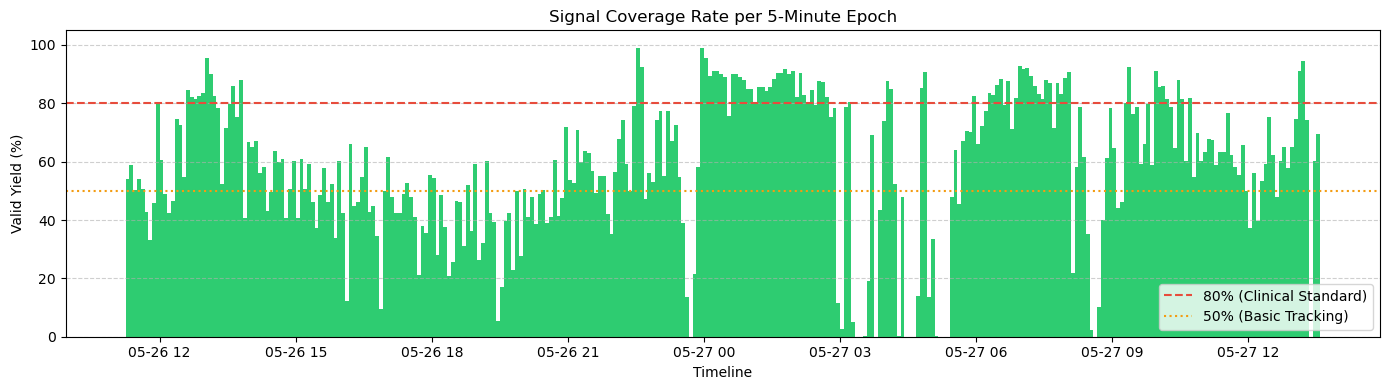

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_time_gaps(df, gap_threshold_s=2.0):
    """
    穿戴设备信号断流分析 (Gap Analysis)
    :param df: 包含 'datetime' 列的特征 DataFrame
    :param gap_threshold_s: 超过多少秒没有心跳判定为一次断流 (默认 2.0 秒，即心率低至 30bpm 以下视为漏检/断流)
    """
    print("="*40)
    print("🚀 信号断流与覆盖率分析报告 (Data Yield)")
    print("="*40)
    
    # 1. 确保时间格式并排序
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], format='%d-%m-%Y %H:%M:%S')
    df = df.sort_values('datetime').reset_index(drop=True)
    
    # 2. 计算相邻两次心跳的时间差 (秒)
    df['time_diff_s'] = df['datetime'].diff().dt.total_seconds()
    
    # 3. 统计全局基础信息
    total_duration_s = (df['datetime'].max() - df['datetime'].min()).total_seconds()
    total_beats = len(df)
    
    # 4. 捕捉断流 (Gap)
    # 只要两次有效心跳之间的间隔大于 gap_threshold_s，就视为一次断流
    gaps = df[df['time_diff_s'] > gap_threshold_s].copy()
    
    total_gap_time_s = gaps['time_diff_s'].sum()
    valid_time_s = total_duration_s - total_gap_time_s
    coverage_rate = (valid_time_s / total_duration_s) * 100 if total_duration_s > 0 else 0
    
    print(f"🕒 总记录时长: {total_duration_s / 3600:.2f} 小时 ({total_duration_s:.0f} 秒)")
    print(f"💓 有效心跳数: {total_beats} 拍")
    print(f"✅ 有效信号时长: {valid_time_s / 3600:.2f} 小时")
    print(f"❌ 绝对断流时长: {total_gap_time_s / 60:.2f} 分钟")
    print(f"🌟 信号覆盖率 (Yield): {coverage_rate:.2f} %")
    print("-" * 40)
    
    if gaps.empty:
        print("🎉 完美信号！没有任何断流。")
        return
        
    print(f"发生断流总次数: {len(gaps)} 次")
    print(f"最大单次断流: {gaps['time_diff_s'].max():.1f} 秒")
    print(f"中位数断流时长: {gaps['time_diff_s'].median():.1f} 秒")
    
    # 5. 断流严重程度分级 (工业界常用分类)
    bins = [gap_threshold_s, 5, 30, 300, np.inf]
    labels = [
        f'微小断流 ({gap_threshold_s}-5s) [通常是吞咽/微动]', 
        '短时断流 (5-30s) [通常是翻身/抬腕]', 
        '中度断流 (30s-5min) [通常是剧烈活动/去洗手间]', 
        '严重断流 (>5min) [通常是设备摘下/传感器失效]'
    ]
    gaps['severity'] = pd.cut(gaps['time_diff_s'], bins=bins, labels=labels)
    
    print("\n📊 断流分级统计:")
    severity_counts = gaps['severity'].value_counts().sort_index()
    for label, count in severity_counts.items():
        if count > 0:
            print(f"   - {label}: {count} 次")
            
# 6. 工业级可视化：计算滑动窗口 (Epoch) 覆盖率
    try:
        print("\n正在生成 5 分钟窗口覆盖率趋势图...")
        # 设定评估窗口大小为 5 分钟 (300秒)
        window_s = 300
        
        # 【修复点 1】：freq='1S' 改为 freq='1s'
        full_idx = pd.date_range(start=df['datetime'].min(), end=df['datetime'].max(), freq='1s')
        
        # 将我们提取出的有效特征映射到这个基底上 (有心跳=1，无心跳=0)
        # 【修复点 2】：resample('1S') 改为 resample('1s')
        valid_seconds = df.set_index('datetime').resample('1s').size() > 0
        
        df_continuous = pd.DataFrame(index=full_idx)
        df_continuous['is_valid'] = valid_seconds.astype(int)
        df_continuous['is_valid'] = df_continuous['is_valid'].fillna(0)
        
        # 计算每 5 分钟内的有效信号比例 (0% ~ 100%)
        # 【修复点 3】：resample(f'{window_s}S') 改为 resample(f'{window_s}s')
        rolling_yield = df_continuous['is_valid'].resample(f'{window_s}s').mean() * 100
        
        # 绘图
        plt.figure(figsize=(14, 4))
        # 绘制绿色柱状图
        plt.bar(rolling_yield.index, rolling_yield.values, 
                width=window_s/(24*3600), color='#2ecc71', align='edge')
        
        # 添加工业标准辅助线
        plt.axhline(y=80, color='#e74c3c', linestyle='--', linewidth=1.5, label='80% (Clinical Standard)')
        plt.axhline(y=50, color='#f39c12', linestyle=':', linewidth=1.5, label='50% (Basic Tracking)')
        
        plt.ylim(0, 105)
        plt.title('Signal Coverage Rate per 5-Minute Epoch')
        plt.ylabel('Valid Yield (%)')
        plt.xlabel('Timeline')
        plt.legend(loc='lower right')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("绘图失败:", e)

# 运行分析
analyze_time_gaps(result_df, gap_threshold_s=2.0)

In [112]:
import pandas as pd
import numpy as np

def audit_timeline(df):
    print("="*50)
    print("🕰️ 时间轴深度审计 (Timeline Audit)")
    print("="*50)
    
    # 1. 确保时间格式并排序 (处理好日/月警告)
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
    df = df.sort_values('datetime').reset_index(drop=True)
    
    # 2. 计算心跳间隔 (相邻两拍之间过了多少秒)
    # 第一拍的 diff 是 NaN，我们后续统计会自动忽略它
    df['interval_s'] = df['datetime'].diff().dt.total_seconds()
    
    # 3. 基础统计
    print("\n📊 1. 心跳间隔全局统计 (秒):")
    print(df['interval_s'].describe().round(2).to_string())
    
    # 4. 揪出所有 > 5分钟的大断流，精准定位时间点
    # 5分钟 = 300秒。我们来看看那 10 个大坑到底在哪。
    major_gaps = df[df['interval_s'] > 300].copy()
    print(f"\n🚨 2. 严重断流清单 (> 5分钟)，共 {len(major_gaps)} 次:")
    
    if not major_gaps.empty:
        for idx, row in major_gaps.iterrows():
            gap_duration = row['interval_s']
            end_time = row['datetime']
            # 断流开始时间 = 这一拍的时间 - 间隔时间
            start_time = end_time - pd.Timedelta(seconds=gap_duration)
            print(f"   - 掉线区间: {start_time.strftime('%Y-%m-%d %H:%M:%S')} 至 {end_time.strftime('%H:%M:%S')} | 持续时长: {gap_duration/60:.1f} 分钟")
    else:
        print("   - 恭喜，无大于 5 分钟的严重断流！")
        
    # 5. 微小断流精细化分布
    print("\n🔍 3. 断流精细化分布频次:")
    bins = [0, 1.5, 3.0, 5.0, 10.0, 30.0, 300.0]
    labels = [
        '正常心跳 (<1.5s)', 
        '极微断流 (1.5-3s)', 
        '微小断流 (3-5s)', 
        '短时断流 (5-10s)', 
        '中短断流 (10-30s)',
        '较长断流 (30s-5min)'
    ]
    cuts = pd.cut(df['interval_s'], bins=bins, labels=labels)
    print(cuts.value_counts().sort_index().to_string())
    
    # 6. 找出最长连续不断流的黄金片段
    # 工业界标准：只要断流超过 5 秒，就算打断了连续性。寻找连续性最强的片段。
    gap_indices = df[df['interval_s'] > 5.0].index.tolist()
    boundaries = [0] + gap_indices + [len(df)]
    
    max_len = 0
    best_start = None
    best_end = None
    
    for i in range(len(boundaries)-1):
        start_idx = boundaries[i]
        # 注意：end_idx 是下一次断流发生的前一拍
        end_idx = boundaries[i+1] - 1 
        if end_idx > start_idx:
            segment_beats = end_idx - start_idx
            if segment_beats > max_len:
                max_len = segment_beats
                best_start = df.loc[start_idx, 'datetime']
                best_end = df.loc[end_idx, 'datetime']
                
    print(f"\n🏆 4. 最长连续无瑕片段 (期间没有任何 > 5秒 的断流):")
    if best_start and best_end:
        duration_mins = (best_end - best_start).total_seconds() / 60
        print(f"   - 时间段: {best_start.strftime('%Y-%m-%d %H:%M:%S')} 至 {best_end.strftime('%H:%M:%S')}")
        print(f"   - 包含心跳: {max_len} 拍 | 绝对连续时长: {duration_mins:.1f} 分钟")

# 直接把你的特征数据扔进去跑
audit_timeline(result_df)

🕰️ 时间轴深度审计 (Timeline Audit)

📊 1. 心跳间隔全局统计 (秒):
count    63704.00
mean         1.48
std         10.33
min          0.00
25%          1.00
50%          1.00
75%          1.00
max       1303.00

🚨 2. 严重断流清单 (> 5分钟)，共 11 次:
   - 掉线区间: 2026-05-26 19:26:07 至 19:32:00 | 持续时长: 5.9 分钟
   - 掉线区间: 2026-05-26 23:37:00 至 23:47:23 | 持续时长: 10.4 分钟
   - 掉线区间: 2026-05-27 03:15:21 至 03:33:35 | 持续时长: 18.2 分钟
   - 掉线区间: 2026-05-27 03:33:35 至 03:38:49 | 持续时长: 5.2 分钟
   - 掉线区间: 2026-05-27 03:44:45 至 03:52:22 | 持续时长: 7.6 分钟
   - 掉线区间: 2026-05-27 04:24:02 至 04:44:09 | 持续时长: 20.1 分钟
   - 掉线区间: 2026-05-27 04:55:45 至 05:03:00 | 持续时长: 7.2 分钟
   - 掉线区间: 2026-05-27 05:05:02 至 05:26:45 | 持续时长: 21.7 分钟
   - 掉线区间: 2026-05-27 08:06:12 至 08:11:26 | 持续时长: 5.2 分钟
   - 掉线区间: 2026-05-27 08:30:56 至 08:42:36 | 持续时长: 11.7 分钟
   - 掉线区间: 2026-05-27 13:18:50 至 13:26:28 | 持续时长: 7.6 分钟

🔍 3. 断流精细化分布频次:
interval_s
正常心跳 (<1.5s)       45586
极微断流 (1.5-3s)       6929
微小断流 (3-5s)         1363
短时断流 (5-10s)        1152
中短断流 (10-30s)      

In [91]:
df.dtypes

Date            str
Time            str
Duration        str
red         float64
ied         float64
accX        float64
accY        float64
accZ        float64
dtype: object

In [20]:
import pandas as pd

def fill_gaps_without_merging(df, max_gap_fill_s=30):
    print("="*50)
    print("🩹 启动无损异步缝合 (全列插值，统一保持整数)")
    print("="*50)
    
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
        df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
    df = df.set_index('datetime').sort_index()
    
    pre_fill_count = len(df)
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1s')
    missing_idx = full_idx.difference(df.index)
    
    filler_df = pd.DataFrame(index=missing_idx, columns=df.columns)
    merged_df = pd.concat([df, filler_df]).sort_index()
    
    # 统一管理所有列
    all_cols = ['rri_raw', 'hr_raw', 'hr_display', 'area_up_ms', 'area_down_ms', 'motion']

    # 1. 安全转为数值型，防止由于脏字符引发报错
    for col in all_cols:
        if col in merged_df.columns:
            merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')
    
    # 2. 对所有生理特征统一进行限制性线性插值
    interpolate_cols = ['rri_raw', 'hr_raw', 'hr_display', 'area_up_ms', 'area_down_ms']
    merged_df[interpolate_cols] = merged_df[interpolate_cols].interpolate(method='linear', limit=max_gap_fill_s)
    
    # 3. 对运动特征缺失部分填 0
    if 'motion' in merged_df.columns:
        merged_df['motion'] = merged_df['motion'].fillna(0, limit=max_gap_fill_s)
        
    # 4. 【核心点】：全部四舍五入并强制转换为可为空的整数类型 (Int64)
    for col in all_cols:
        if col in merged_df.columns:
            merged_df[col] = merged_df[col].round(0).astype('Int64')
            
    post_fill_count = len(merged_df.dropna(subset=['hr_display']))
    
    print("\n✅ 重建完成！效果对比：")
    print(f"   - 有效心跳行数从 {pre_fill_count} 提升至 {post_fill_count}")
    print(f"   - 成功拯救(插值)数据: {post_fill_count - pre_fill_count} 拍\n")
    
    return merged_df

# 运行代码
final_hybrid_df = fill_gaps_without_merging(result_df, max_gap_fill_s=30)

🩹 启动无损异步缝合 (全列插值，统一保持整数)

✅ 重建完成！效果对比：
   - 有效心跳行数从 63664 提升至 93760
   - 成功拯救(插值)数据: 30096 拍



In [21]:
final_hybrid_df

,rri_raw,hr_raw,hr_display,area_up_ms,area_down_ms,motion
2026-05-26 11:15:43,1159,52,51,126,428,142
2026-05-26 11:15:44,1114,55,51,125,413,0
2026-05-26 11:15:45,1069,58,52,125,398,0
2026-05-26 11:15:46,1024,61,52,124,383,0
2026-05-26 11:15:47,980,64,53,124,368,0
...,...,...,...,...,...,...
2026-05-27 13:31:30,827,73,63,109,222,<NA>
2026-05-27 13:31:31,826,73,63,99,204,<NA>
2026-05-27 13:31:32,825,73,64,89,186,<NA>
2026-05-27 13:31:33,824,73,64,78,168,<NA>



=== 基于插值整数数据集的 HRV 指标 ===
参与绘图心跳数: 93760
SD1 (短期变异性): 141.84 ms
SD2 (长期变异性): 348.94 ms


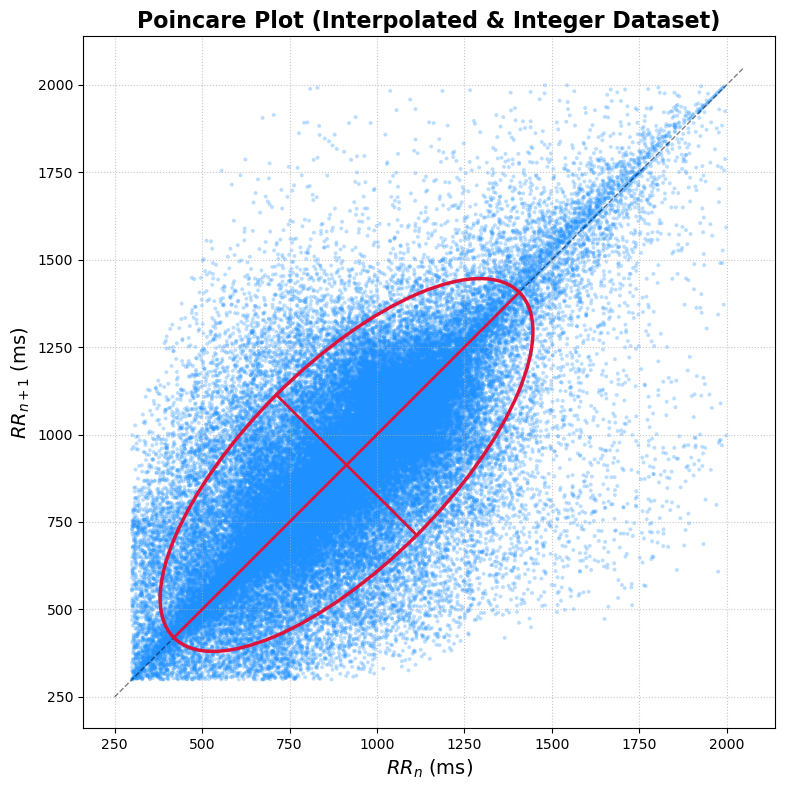

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

def plot_poincare_from_hybrid(df):
    # 1. 提取 rri_raw，剔除掉由于严重断连导致的 <NA> 值
    # 必须先 dropna()，然后再转换回标准的 float 类型以便 numpy 和 matplotlib 计算
    valid_rri = df['rri_raw'].dropna().astype(float).values
    
    # 过滤掉不合理的异常 0 值
    rri_ms = valid_rri[valid_rri > 0]

    if len(rri_ms) < 2:
        print("有效数据不足，无法绘制 Poincare 图。")
        return

    # 2. 构造 RR_n 和 RR_n+1 序列
    rr_n = rri_ms[:-1]
    rr_n_plus_1 = rri_ms[1:]

    # ==========================================
    # 3. 毫秒级计算核心 HRV 散点图指标
    # ==========================================
    sdnn = np.std(rri_ms, ddof=1)
    sdsd = np.std(rr_n_plus_1 - rr_n, ddof=1)
    sd1 = sdsd / np.sqrt(2)
    sd2 = np.sqrt(2 * sdnn**2 - sd1**2)

    print("\n=== 基于插值整数数据集的 HRV 指标 ===")
    print(f"参与绘图心跳数: {len(rri_ms)}")
    print(f"SD1 (短期变异性): {sd1:.2f} ms")
    print(f"SD2 (长期变异性): {sd2:.2f} ms")

    # ==========================================
    # 4. 绘制图表
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 绘制散点
    ax.scatter(rr_n, rr_n_plus_1, c='dodgerblue', s=8, alpha=0.3, edgecolor='none')

    mean_rr = np.mean(rri_ms)

    # 画置信椭圆
    ellipse = Ellipse((mean_rr, mean_rr), width=4*sd2, height=4*sd1, 
                      angle=45, fill=False, edgecolor='crimson', lw=2.5, zorder=3)
    ax.add_patch(ellipse)

    # 画十字交叉轴
    dx2 = 2 * sd2 * np.cos(np.radians(45))
    dy2 = 2 * sd2 * np.sin(np.radians(45))
    ax.plot([mean_rr - dx2, mean_rr + dx2], [mean_rr - dy2, mean_rr + dy2], 'crimson', lw=2, zorder=3)

    dx1 = 2 * sd1 * np.cos(np.radians(135))
    dy1 = 2 * sd1 * np.sin(np.radians(135))
    ax.plot([mean_rr - dx1, mean_rr + dx1], [mean_rr - dy1, mean_rr + dy1], 'crimson', lw=2, zorder=3)

    # 图表边界自适应
    min_bound = np.min(rri_ms) - 50
    max_bound = np.max(rri_ms) + 50
    
    ax.plot([min_bound, max_bound], [min_bound, max_bound], 'k--', lw=1, alpha=0.5)

    # ax.set_xlim(min_bound, max_bound)
    # ax.set_ylim(min_bound, max_bound)
    ax.set_aspect('equal', 'box') 
    
    ax.set_title('Poincare Plot (Interpolated & Integer Dataset)', fontsize=16, fontweight='bold')
    ax.set_xlabel('$RR_n$ (ms)', fontsize=14)
    ax.set_ylabel('$RR_{n+1}$ (ms)', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

# 调用函数画图
plot_poincare_from_hybrid(final_hybrid_df)

📈 启动每分钟心率趋势聚合 (1-Min Aggregation)
✅ 聚合完成！数据点从 94552 秒压缩至 1577 分钟。


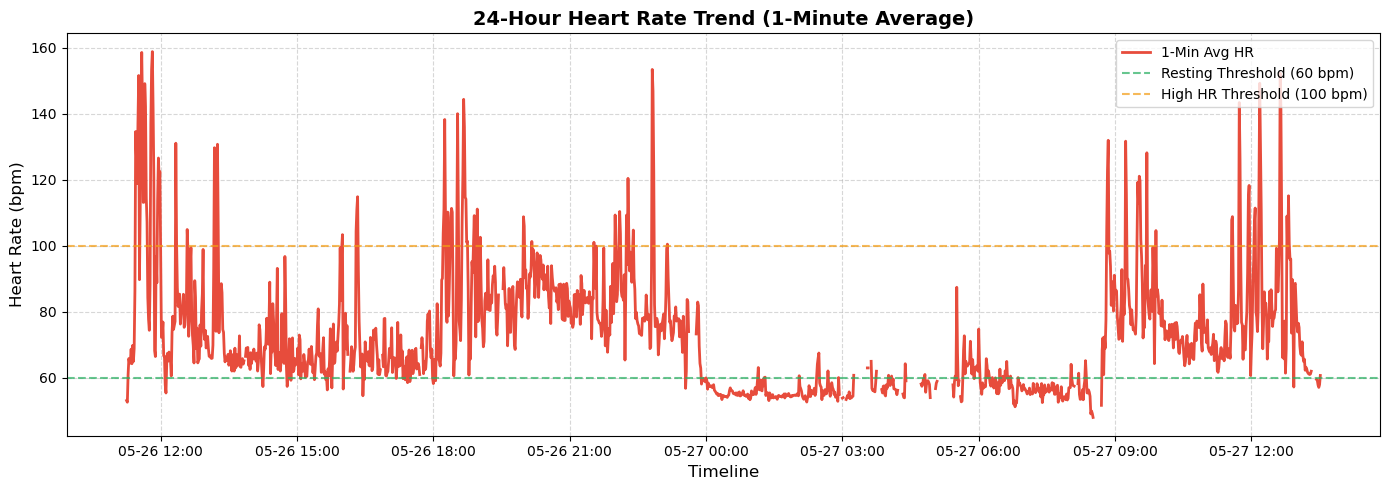

In [118]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

def plot_minute_avg_hr(df):
    print("="*50)
    print("📈 启动每分钟心率趋势聚合 (1-Min Aggregation)")
    print("="*50)
    
    # 1. 安全降级：把 Int64 转回 float，确保计算均值和绘图不出错
    df_hr = df['hr_display'].astype(float)
    
    # 2. 核心降维：按 1 分钟 (1min) 重新采样并计算均值
    # 注意：旧版 Pandas 用 '1T'，新版必须用 '1min'
    df_1min = df_hr.resample('1min').mean()
    
    print(f"✅ 聚合完成！数据点从 {len(df_hr)} 秒压缩至 {len(df_1min)} 分钟。")
    
    # 3. 开始绘图
    plt.figure(figsize=(14, 5))
    
    # 画出折线，遇到 NaN 会自动断开
    plt.plot(df_1min.index, df_1min.values, color='#e74c3c', linewidth=2, label='1-Min Avg HR')
    
    # 4. 图表美化与工业风排版
    plt.title('24-Hour Heart Rate Trend (1-Minute Average)', fontsize=14, fontweight='bold')
    plt.ylabel('Heart Rate (bpm)', fontsize=12)
    plt.xlabel('Timeline', fontsize=12)
    
    # 标出一些健康的参考线 (例如 60 bpm 和 100 bpm)
    plt.axhline(y=60, color='#27ae60', linestyle='--', alpha=0.7, label='Resting Threshold (60 bpm)')
    plt.axhline(y=100, color='#f39c12', linestyle='--', alpha=0.7, label='High HR Threshold (100 bpm)')
    
    # 格式化 X 轴时间显示
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    return df_1min

# 把上一轮经过 1Hz 插值且修正了极性的 final_feature_df 传进去
hr_1min_df = plot_minute_avg_hr(continuous_df)

In [24]:
final = final_hybrid_df[['rri_raw', 'area_up_ms', 'area_down_ms', 'motion']]

In [25]:
final

,rri_raw,area_up_ms,area_down_ms,motion
2026-05-26 11:15:43,1159,126,428,142
2026-05-26 11:15:44,1114,125,413,0
2026-05-26 11:15:45,1069,125,398,0
2026-05-26 11:15:46,1024,124,383,0
2026-05-26 11:15:47,980,124,368,0
...,...,...,...,...
2026-05-27 13:31:30,827,109,222,<NA>
2026-05-27 13:31:31,826,99,204,<NA>
2026-05-27 13:31:32,825,89,186,<NA>
2026-05-27 13:31:33,824,78,168,<NA>


In [27]:
import pandas as pd

def force_fill_all_nans(df):
    print("="*50)
    print("🚀 启动全量无死角插值 (Force Fill All NaNs)")
    print("="*50)
    
    clean_df = df.copy()
    physio_cols = ['rri_raw', 'area_up_ms', 'area_down_ms']
    
    # 1. 核心破壁：去掉 limit 参数，允许跨越无限长度的断流进行线性估值
    print("-> 正在执行无限制线性插值 (跨越所有大断崖)...")
    clean_df[physio_cols] = clean_df[physio_cols].interpolate(method='linear')
    
    # 2. 边缘兜底：针对头部或尾部的悬空 NaN，使用最近邻方法 (向后/向前复制)
    print("-> 正在执行最近邻兜底 (处理首尾边缘空洞)...")
    clean_df[physio_cols] = clean_df[physio_cols].bfill().ffill()
    
    # 3. 确保体动列 100% 填 0 (以防万一前面没处理干净)
    if 'motion' in clean_df.columns:
        clean_df['motion'] = clean_df['motion'].fillna(0)
        
    # 4. 强制舍入并转回 Int64
    target_cols = ['rri_raw', 'area_up_ms', 'area_down_ms', 'motion']
    for col in target_cols:
        clean_df[col] = clean_df[col].round(0).astype('Int64')
        
    print("\n✅ 强制填补完成！最后的 NaN 审计：")
    print(clean_df.isna().sum())
    
    return clean_df

# 将包含 NaN 的数据集传进去
final_dense_df = force_fill_all_nans(final)

🚀 启动全量无死角插值 (Force Fill All NaNs)
-> 正在执行无限制线性插值 (跨越所有大断崖)...
-> 正在执行最近邻兜底 (处理首尾边缘空洞)...

✅ 强制填补完成！最后的 NaN 审计：
rri_raw         0
area_up_ms      0
area_down_ms    0
motion          0
dtype: int64


In [28]:
final_dense_df = final_dense_df.reset_index()

In [29]:
final_dense_df.columns = ["timestamp", 'rri_ms', 'asc_area', 'desc_area', 'motion']

In [31]:
final_dense_df.to_csv("wang_ring2.csv", index=False)

In [134]:
a = final_dense_df.timestamp

In [141]:
b = (a.iloc[-1] - a.iloc[0])

In [144]:
b.total_seconds()

94551.0